<a href="https://colab.research.google.com/github/fabiocf12/MPA-MLF-exercises/blob/main/lab7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from tensorflow import keras
from keras.models import Sequential
from keras.datasets import mnist
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
###################################
# Write your own code here #
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

###################################
font = {'weight' : 'bold',
        'size'   : 12}

matplotlib.rc('font', **font)

In [ ]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
def display_random_images(x_data: np.array, y_data: np.array, count: int = 10) -> None:
  index = np.array(len(x_data))
  selected_ind = np.random.choice(index, count)

  selected_img = x_data[selected_ind]
  selected_labels = y_data[selected_ind]
  concat_img = np.concatenate(selected_img, axis=1)

  plt.figure(figsize=(20,10))
  plt.imshow(concat_img, cmap="gray")

  for id_label, label in enumerate(selected_labels):
    plt.text(14 + 28*id_label, 28*(5/4), label)
  plt.axis('off')
  plt.show()

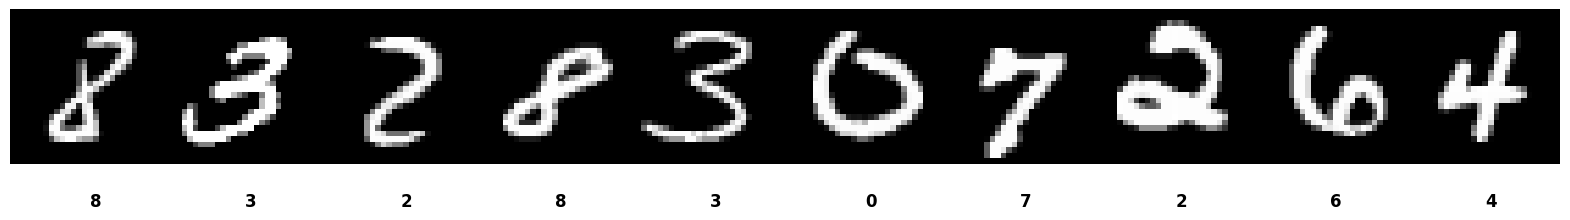

In [ ]:
display_random_images(X_train, y_train)

QUESTIONS :

What kind of data occurs in our dataset?
Grayscale images of handwritten digits 0-9.

How many data samples do we have in train and test datasets?
60,000 training samples and 10,000 test samples.

How many colour channels does the input variable have?
1 channel

What is the size of the input images?
28 X 28 pixels

What is the necessary preprocessing of the input data X?
Reshaping: From 28x28 to 28x28x1 to specify the channel.
Normalization: Scaling pixel values from 0-255 to 0-1.

How many classes do we have in target varoable?
10 classes. 0 to 9 digits.

What is the necessary preprocessing of target variable y?
One-hot encoding: Converting integers (e.g., 5) into categorical vectors

In [ ]:
print(X_train.shape)
print(X_test.shape)

(60000, 28, 28)
(10000, 28, 28)


In [ ]:
#1.3 Dataset preprocessing

# 1. Reshape to add 1 color channel

X_train = X_train.reshape(-1, 28, 28, 1).astype('float32')
X_test = X_test.reshape(-1, 28, 28, 1).astype('float32')

# 2. Normalization Min-Max
# Pixels go from 0-255, so we divide by 255
X_train /= 255
X_test /= 255

# 3. One-Hot Encoding for y
# 5 becomes [0, 0, 0, 0, 0, 1, 0, 0, 0, 0]
y_train = to_categorical(y_train, num_classes=10)
y_test = to_categorical(y_test, num_classes=10)

print(f"Shape do X_train: {X_train.shape}")
print(f"Exemplo de label (y) após encoding: {y_train[0]}")


Shape do X_train: (60000, 28, 28, 1)
Exemplo de label (y) após encoding: [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


In [ ]:
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential()

# 1. Convolutional_layero
model.add(Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1)))

# Bloco 2 (Novo!)
Conv2D(64, kernel_size=(3, 3), activation='relu'),

# 2. max poolinglayer
model.add(MaxPooling2D(pool_size=(2, 2)))

# 3.Flatten
# matrix 2d goes to 1d
model.add(Flatten())

# We add a dense layer with 128 neurons to learn complex combinations
model.add(Dense(128, activation='relu'))
# Dropout(0.5) means 50% of these 128 neurons are randomly disabled every training step
model.add(Dropout(0.5))
# -----------------------------------

# 4. output layer
model.add(Dense(10, activation='softmax'))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 5408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       692,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 693,962 (2.65 MB)

 Trainable params: 693,962 (2.65 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Compile the model

# multiclasse with One-Hot Encoding, use categorical_crossentropy
loss = 'categorical_crossentropy'
learning_rate = 0.001
optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
metrics = ['accuracy']

###################################
# Write your own code here #

model.compile(optimizer=optimizer,
              loss=loss,
              metrics=metrics,)

###################################
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 5408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       692,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 693,962 (2.65 MB)

 Trainable params: 693,962 (2.65 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
batch_size = 64
epochs = 30
validation_split = 0.2

history = model.fit(
    X_train, y_train,
    batch_size=batch_size,
    epochs=epochs,
    validation_split=validation_split,
)

Epoch 1/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 32s 40ms/step - accuracy: 0.9087 - loss: 0.3066 - val_accuracy: 0.9736 - val_loss: 0.0873
Epoch 2/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 31s 41ms/step - accuracy: 0.9663 - loss: 0.1156 - val_accuracy: 0.9822 - val_loss: 0.0617
Epoch 3/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 29s 39ms/step - accuracy: 0.9736 - loss: 0.0879 - val_accuracy: 0.9836 - val_loss: 0.0560
Epoch 4/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 39s 37ms/step - accuracy: 0.9783 - loss: 0.0704 - val_accuracy: 0.9855 - val_loss: 0.0524
Epoch 5/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 41s 37ms/step - accuracy: 0.9816 - loss: 0.0597 - val_accuracy: 0.9858 - val_loss: 0.0495
Epoch 6/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 28s 37ms/step - accuracy: 0.9840 - loss: 0.0502 - val_accuracy: 0.9865 - val_loss: 0.0505
Epoch 7/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 42s 39ms/step - accuracy: 0.9857 - loss: 0.0452 - val_accuracy: 0.9867 - val_loss: 0.0471
Epoch 8/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 42s 40ms/step - accuracy: 0.9874 - loss: 0.0406 - 

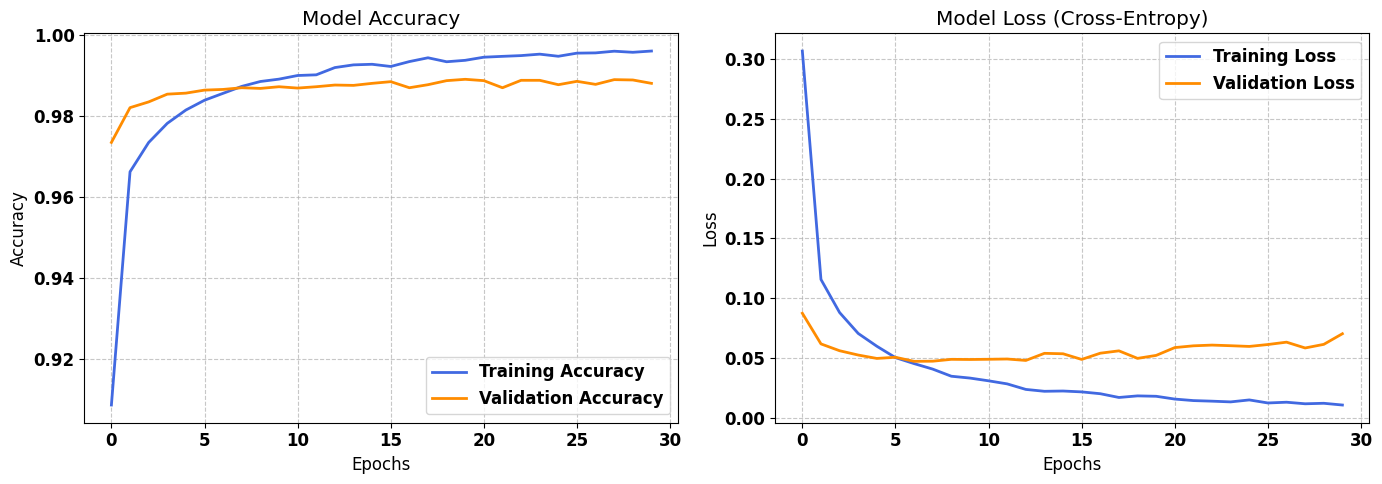

In [ ]:
import matplotlib.pyplot as plt

# Create a figure with two subplots
plt.figure(figsize=(14, 5))

# --- Plot 1: Accuracy ---
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy', color='royalblue', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='darkorange', linewidth=2)
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.7)

# --- Plot 2: Loss ---
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss', color='royalblue', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', color='darkorange', linewidth=2)
plt.title('Model Loss (Cross-Entropy)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

--- Final Test Results ---
Test Accuracy: 98.85%
Test Loss: 0.0556

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       980
           1       0.99      1.00      1.00      1135
           2       0.99      0.99      0.99      1032
           3       0.99      0.99      0.99      1010
           4       0.99      0.99      0.99       982
           5       0.99      0.98      0.99       892
           6       0.99      0.99      0.99       958
           7       0.99      0.99      0.99      1028
           8       0.99      0.98      0.99       974
           9       0.99      0.98      0.98      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



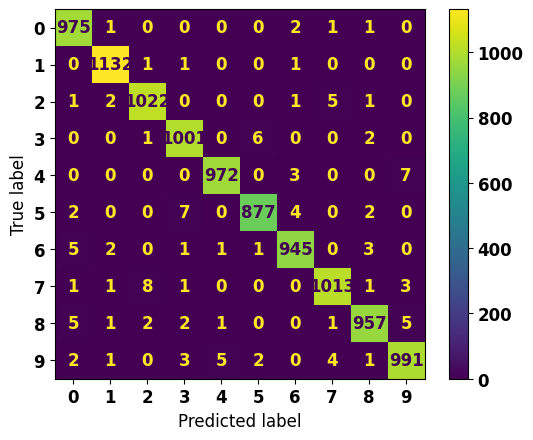

In [ ]:
#4. Model evaluation

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report,ConfusionMatrixDisplay


# 1. Evaluate the model on the test dataset
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)

print(f"--- Final Test Results ---")
print(f"Test Accuracy: {test_acc*100:.2f}%")
print(f"Test Loss: {test_loss:.4f}\n")

# 2. Generate predictions
# The model outputs probabilities (Softmax), so we take the highest value (Argmax)
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

# 3. Create the Confusion Matrix
cm = confusion_matrix(y_true_classes, y_pred_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot()

# 5. Display the Classification Report
# This shows Precision, Recall, and F1-Score for every single digit
print("Classification Report:")
print(classification_report(y_true_classes, y_pred_classes))